# Versión operativa basada en V2.4 Configurable Multimercado

Mantiene la lógica operativa de V2.3 e incorpora un calendario de resultados compacto y tabular.


In [13]:
# ========================= CONFIGURACIÓN =========================
# Activos que aparecerán en el panel.
ACTIVOS = [
    'META',
    'SHOP',
    # 'AAPL',
    # 'NVDA',
    # 'MSFT',
    # 'AMZN',
]

# Deja descomentada EXACTAMENTE UNA línea.
# MODO_OPERATIVO = 'SOLO_LONG'
# MODO_OPERATIVO = 'SOLO_SHORT'
MODO_OPERATIVO = 'LONG_Y_SHORT'

# Fecha hasta la que se analizarán cierres. None/'HOY' utiliza hoy.
FECHA_FIN = None
# FECHA_FIN = '2026-08-26'

# Estado que realmente tienes en IBKR Paper.
# Si estás fuera, usa {'lado': None}.
# Si estás dentro, rellena lado, sistema, fecha y precio REAL de ejecución.
# Sistemas LONG válidos:  'RSI + BOLLINGER'
# Sistemas SHORT válidos: 'RSI > 70' o 'RUPTURA'
POSICIONES_PAPER = {
    'META': {'lado': None},
    'SHOP': {'lado': None},
    # Ejemplo:
    # 'META': {
    #     'lado': 'SHORT', 'sistema': 'RUPTURA',
    #     'fecha': '2026-08-20', 'precio': 535.25
    # },
}

# Parámetros originales de V2.2.
AJUSTAR_DIVIDENDOS = True
STOP_LONG = 0.07
STOP_SHORT = 0.07
PERIODO_RUPTURA = 20
MULTIPLICADOR_VOLUMEN = 1.00
RUPTURA_ATR = 2.0
RUPTURA_MAX_SESIONES = 20
# ================================================================


In [14]:
# ================= IMPORTACIÓN Y DESCARGA =================
import warnings
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from dateutil.relativedelta import relativedelta
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
yf.set_tz_cache_location(str(Path(tempfile.gettempdir()) / 'yf_operativa_v22_cache'))

tickers = [str(t).strip().upper() for t in ACTIVOS]
if not tickers or len(tickers) != len(set(tickers)):
    raise ValueError('ACTIVOS debe contener tickers únicos y al menos uno.')

MODO_OPERATIVO = str(MODO_OPERATIVO).strip().upper()
if MODO_OPERATIVO not in {'SOLO_LONG', 'SOLO_SHORT', 'LONG_Y_SHORT'}:
    raise ValueError("Modo inválido: usa SOLO_LONG, SOLO_SHORT o LONG_Y_SHORT.")

hoy = pd.Timestamp.today().normalize()
fecha_fin_solicitada = (
    hoy if FECHA_FIN is None or str(FECHA_FIN).strip().upper() == 'HOY'
    else pd.Timestamp(FECHA_FIN).normalize()
)
if fecha_fin_solicitada > hoy:
    raise ValueError('FECHA_FIN no puede ser posterior a hoy.')

# Cinco años mantienen el calentamiento de indicadores del V2.2.
inicio_descarga = fecha_fin_solicitada - relativedelta(years=5)
datos_raw, errores = {}, []
for ticker in tickers:
    try:
        d = yf.download(
            ticker, start=inicio_descarga,
            end=fecha_fin_solicitada + pd.Timedelta(days=1),
            interval='1d', auto_adjust=AJUSTAR_DIVIDENDOS, progress=False
        )
        if d.empty:
            raise RuntimeError('descarga vacía')
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.get_level_values(0)
        d = d[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()
        d.index = pd.DatetimeIndex(d.index).tz_localize(None).normalize()
        datos_raw[ticker] = d[~d.index.duplicated(keep='last')].sort_index()
    except Exception as exc:
        errores.append(f'{ticker}: {exc}')

if errores:
    raise RuntimeError('Error de descarga:\n' + '\n'.join(errores))

# Última sesión que existe simultáneamente para todos los activos.
sesiones_comunes = set.intersection(*(set(d.index) for d in datos_raw.values()))
if not sesiones_comunes:
    raise RuntimeError('Los activos no tienen sesiones comunes.')
ultima_fecha_comun = max(sesiones_comunes)


In [15]:
# ================= INDICADORES Y SEÑALES V2.2 =================
def preparar_senales(df):
    """Reproduce las señales del Backtester V2.2 sin lookahead."""
    d = df.copy()
    delta = d['Close'].diff()
    subida, bajada = delta.clip(lower=0), -delta.clip(upper=0)
    rs = subida.rolling(14).mean() / bajada.rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + rs)

    d['BB_MIDDLE'] = d['Close'].rolling(20).mean()
    desviacion = d['Close'].rolling(20).std()
    d['BB_LOWER'] = d['BB_MIDDLE'] - 2 * desviacion
    d['EMA10'] = d['Close'].ewm(span=10, adjust=False).mean()

    cierre_previo = d['Close'].shift(1)
    tr = pd.concat([
        d['High'] - d['Low'],
        (d['High'] - cierre_previo).abs(),
        (d['Low'] - cierre_previo).abs()
    ], axis=1).max(axis=1)
    d['ATR14'] = tr.ewm(alpha=1 / 14, adjust=False).mean()

    d['LONG_ENTRY'] = (d['RSI'] < 30) & (d['Close'] <= d['BB_LOWER'])
    d['LONG_EXIT'] = (d['RSI'] >= 65) | (d['Close'] >= d['BB_MIDDLE'])
    d['MINIMO_20_PREV'] = d['Low'].rolling(PERIODO_RUPTURA).min().shift(1)
    d['VOLUMEN_20_PREV'] = d['Volume'].rolling(PERIODO_RUPTURA).mean().shift(1)
    d['SHORT_RSI'] = d['RSI'] > 70
    d['SHORT_RUPTURA'] = (
        (d['Close'] < d['MINIMO_20_PREV'])
        & (d['Volume'] > d['VOLUMEN_20_PREV'] * MULTIPLICADOR_VOLUMEN)
    )
    return d


datos = {
    ticker: preparar_senales(d.loc[d.index <= ultima_fecha_comun])
    for ticker, d in datos_raw.items()
}


In [16]:
# ================= EVALUACIÓN OPERATIVA =================
def estado_configurado(ticker):
    estado = POSICIONES_PAPER.get(ticker, {'lado': None})
    lado = estado.get('lado')
    if lado is None or str(lado).strip().upper() in {'', 'NINGUNO', 'FUERA', 'NONE'}:
        return {'lado': None}
    return {**estado, 'lado': str(lado).strip().upper()}


def trailing_ruptura(d, fecha_entrada, precio_entrada):
    """Reconstruye causalmente el trailing que V2.2 habría acumulado."""
    tramo = d.loc[d.index >= fecha_entrada]
    trailing = precio_entrada * (1 + STOP_SHORT)
    minimo_desde_entrada = precio_entrada
    for _, fila in tramo.iterrows():
        minimo_desde_entrada = min(minimo_desde_entrada, float(fila['Low']))
        if pd.notna(fila['ATR14']):
            candidato = minimo_desde_entrada + RUPTURA_ATR * float(fila['ATR14'])
            trailing = min(trailing, candidato)
    return trailing, len(tramo)


def evaluar(ticker):
    d = datos[ticker]
    actual = d.iloc[-1]
    fecha_actual = d.index[-1]
    cierre = float(actual['Close'])
    estado = estado_configurado(ticker)

    # Estando fuera, solo una señal del último cierre autoriza una entrada en
    # la próxima apertura. No se persiguen señales históricas atrasadas.
    if estado['lado'] is None:
        if MODO_OPERATIVO != 'SOLO_SHORT' and bool(actual['LONG_ENTRY']):
            return {
                'accion': 'ENTRAR LONG', 'momento': 'PRÓXIMA APERTURA',
                'sistema': 'RSI + BOLLINGER',
                'motivo': f"RSI {actual['RSI']:.1f} y cierre bajo la banda inferior de Bollinger.",
                'stop': cierre * (1 - STOP_LONG),
                'nota_stop': 'Stop orientativo; recalcular al 7% bajo el precio real de ejecución.'
            }
        if MODO_OPERATIVO != 'SOLO_LONG' and bool(actual['SHORT_RUPTURA']):
            return {
                'accion': 'ENTRAR SHORT', 'momento': 'PRÓXIMA APERTURA',
                'sistema': 'RUPTURA',
                'motivo': 'Cierre bajo el mínimo previo de 20 sesiones con volumen superior a su media.',
                'stop': cierre * (1 + STOP_SHORT),
                'nota_stop': 'Stop orientativo; recalcular al 7% sobre el precio real de ejecución.'
            }
        if MODO_OPERATIVO != 'SOLO_LONG' and bool(actual['SHORT_RSI']):
            return {
                'accion': 'ENTRAR SHORT', 'momento': 'PRÓXIMA APERTURA',
                'sistema': 'RSI > 70',
                'motivo': f"RSI en sobrecompra: {actual['RSI']:.1f}.",
                'stop': cierre * (1 + STOP_SHORT),
                'nota_stop': 'Stop orientativo; recalcular al 7% sobre el precio real de ejecución.'
            }
        return {
            'accion': 'PERMANECER FUERA', 'momento': 'AHORA', 'sistema': '—',
            'motivo': f"No hay señal nueva al cierre. RSI: {actual['RSI']:.1f}.",
            'stop': None, 'nota_stop': ''
        }

    # Para gestionar una posición real son imprescindibles estos tres campos.
    faltan = [k for k in ('sistema', 'fecha', 'precio') if estado.get(k) in (None, '')]
    if faltan:
        return {
            'accion': 'REVISAR POSICIÓN', 'momento': 'AHORA', 'sistema': estado.get('sistema', '—'),
            'motivo': 'Faltan en POSICIONES_PAPER: ' + ', '.join(faltan) + '.',
            'stop': None, 'nota_stop': ''
        }

    lado = estado['lado']
    sistema = str(estado['sistema']).strip().upper()
    fecha_entrada = pd.Timestamp(estado['fecha']).normalize()
    precio_entrada = float(estado['precio'])
    if fecha_entrada not in d.index:
        return {
            'accion': 'REVISAR POSICIÓN', 'momento': 'AHORA', 'sistema': sistema,
            'motivo': 'La fecha de entrada no aparece en el histórico descargado.',
            'stop': None, 'nota_stop': ''
        }

    if lado == 'LONG':
        stop = precio_entrada * (1 - STOP_LONG)
        if bool(actual['LONG_EXIT']):
            motivo = f"Salida LONG activada: RSI {actual['RSI']:.1f} o cierre sobre banda media."
            accion, momento = 'SALIR LONG', 'PRÓXIMA APERTURA'
        else:
            motivo = f"LONG vigente: RSI {actual['RSI']:.1f}; no se activó la salida."
            accion, momento = 'MANTENER LONG', 'AHORA'

    elif lado == 'SHORT' and sistema == 'RSI > 70':
        stop = precio_entrada * (1 + STOP_SHORT)
        if bool(actual['RSI'] < 50):
            motivo = f"Salida SHORT RSI activada: RSI {actual['RSI']:.1f} < 50."
            accion, momento = 'SALIR SHORT', 'PRÓXIMA APERTURA'
        else:
            motivo = f"SHORT RSI vigente: RSI {actual['RSI']:.1f} todavía no es inferior a 50."
            accion, momento = 'MANTENER SHORT', 'AHORA'

    elif lado == 'SHORT' and sistema == 'RUPTURA':
        stop, sesiones = trailing_ruptura(d, fecha_entrada, precio_entrada)
        dos_sobre_ema = len(d) >= 2 and bool(
            (d['Close'].iloc[-2:] > d['EMA10'].iloc[-2:]).all()
        )
        if dos_sobre_ema:
            accion, momento = 'SALIR SHORT', 'PRÓXIMA APERTURA'
            motivo = 'Dos cierres consecutivos por encima de EMA10.'
        elif bool(actual['RSI'] > 55):
            accion, momento = 'SALIR SHORT', 'PRÓXIMA APERTURA'
            motivo = f"RSI {actual['RSI']:.1f} > 55: final de la ruptura bajista."
        elif sesiones >= RUPTURA_MAX_SESIONES:
            accion, momento = 'SALIR SHORT', 'PRÓXIMA APERTURA'
            motivo = f"Alcanzado el máximo de {RUPTURA_MAX_SESIONES} sesiones."
        else:
            accion, momento = 'MANTENER SHORT', 'AHORA'
            motivo = f"Ruptura vigente durante {sesiones} sesiones; trailing ATR activo."
    else:
        return {
            'accion': 'REVISAR POSICIÓN', 'momento': 'AHORA', 'sistema': sistema,
            'motivo': f"Combinación no válida de lado ({lado}) y sistema ({sistema}).",
            'stop': None, 'nota_stop': ''
        }

    if (lado == 'LONG' and cierre <= stop) or (lado == 'SHORT' and cierre >= stop):
        accion, momento = 'REVISAR STOP', 'INMEDIATAMENTE'
        motivo = 'El último cierre ha atravesado el stop registrado; comprueba la ejecución en IBKR Paper.'

    return {
        'accion': accion, 'momento': momento, 'sistema': sistema,
        'motivo': motivo, 'stop': stop,
        'nota_stop': 'Orden de protección; un gap puede ejecutarse a un precio peor.'
    }


estados = {ticker: evaluar(ticker) for ticker in tickers}


## Calendario dinámico de resultados — V2.4

Tabla compacta para los valores seleccionados en `ACTIVOS`. Muestra los dos últimos resultados, noticias traducidas al español y la reacción bursátil de cada anuncio. Las fuentes combinan la web/comunicado oficial con hasta tres medios fiables y se guardan en caché.

La zona neutral es ±3 %. Las mismas dos fechas se comparten con los gráficos de tres y seis meses.


In [17]:
# INFORME DINÁMICO DE RESULTADOS — V2.4 (DOS ÚLTIMOS RESULTADOS)
# Ejecutar antes de la celda de gráficos. No transmite órdenes ni opera.
from datetime import date, datetime, timedelta
from email.utils import parsedate_to_datetime
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.parse import quote, urlencode
from urllib.request import Request, urlopen
from html import escape, unescape
import json
import re
import xml.etree.ElementTree as ET

import pandas as pd
import yfinance as yf
from dateutil import parser as date_parser
from IPython.display import HTML, display

FUENTES_IR = {
    "META": "https://investor.atmeta.com/investor-events/default.aspx",
    "SHOP": "https://www.shopify.com/investors/events",
    "NVDA": "https://investor.nvidia.com/events-and-presentations/events-and-presentations/default.aspx",
    "MSFT": "https://www.microsoft.com/en-us/investor/events/events-upcoming",
    "AAPL": "https://investor.apple.com/investor-relations/default.aspx",
    "AMZN": "https://ir.aboutamazon.com/events/",
    "GOOGL": "https://abc.xyz/investor/",
    "GOOG": "https://abc.xyz/investor/",
    "TSLA": "https://ir.tesla.com/",
    "AVGO": "https://investors.broadcom.com/events-and-presentations",
}
NOMBRES_BUSQUEDA = {
    "META": '"Meta Platforms" earnings', "SHOP": '"Shopify" earnings',
    "NVDA": '"NVIDIA" earnings', "MSFT": '"Microsoft" earnings',
    "AAPL": '"Apple" earnings', "AMZN": '"Amazon" earnings',
    "GOOGL": '"Alphabet" earnings', "GOOG": '"Alphabet" earnings',
    "TSLA": '"Tesla" earnings', "AVGO": '"Broadcom" earnings',
}
FUENTES_EMPRESA = {
    "META": {"meta investor relations", "meta"},
    "SHOP": {"shopify"},
    "NVDA": {"nvidia investor relations", "nvidia newsroom", "nvidia"},
    "MSFT": {"microsoft investor relations", "microsoft"},
    "AAPL": {"apple"},
    "AMZN": {"amazon investor relations", "about amazon", "amazon"},
    "GOOGL": {"alphabet investor relations", "alphabet"},
    "GOOG": {"alphabet investor relations", "alphabet"},
    "TSLA": {"tesla investor relations", "tesla"},
    "AVGO": {"broadcom investor relations", "broadcom"},
}
MEDIOS_PRIORITARIOS = (
    "Reuters", "AP News", "CNBC", "MarketWatch", "WSJ", "Bloomberg",
    "Financial Times", "Barron's", "U.S. News & World Report", "Fortune",
    "Morningstar", "Yahoo Finance",
)
DISTRIBUIDORES_OFICIALES = {"PR Newswire", "GlobeNewswire", "Business Wire"}
PALABRAS_RESULTADOS = re.compile(
    r"earnings|financial results|quarterly results|earnings call|results conference|"
    r"reports? .{0,35}(?:quarter|results)|delivers|resultados|conference call",
    re.IGNORECASE,
)
PATRONES_FECHA = [
    re.compile(
        r"\b(?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|Jun(?:e)?|"
        r"Jul(?:y)?|Aug(?:ust)?|Sep(?:tember)?|Oct(?:ober)?|Nov(?:ember)?|"
        r"Dec(?:ember)?)\.?\s+\d{1,2}(?:st|nd|rd|th)?[,]?\s+20\d{2}\b", re.I
    ),
    re.compile(
        r"\b\d{1,2}\s+(?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|"
        r"Jun(?:e)?|Jul(?:y)?|Aug(?:ust)?|Sep(?:tember)?|Oct(?:ober)?|"
        r"Nov(?:ember)?|Dec(?:ember)?)\s+20\d{2}\b", re.I
    ),
]

UMBRAL_NEUTRAL_PCT = 3.0
CARPETA_CALENDARIO = Path("salida_operativa") / "calendario_resultados"
CARPETA_CALENDARIO.mkdir(parents=True, exist_ok=True)
ARCHIVO_ESTADO = CARPETA_CALENDARIO / "estado_fechas_v2_4.json"
ARCHIVO_HTML = CARPETA_CALENDARIO / "informe_resultados.html"


def descargar(url, timeout=25):
    req = Request(url, headers={"User-Agent": "Mozilla/5.0 CalendarioResultados/2.4"})
    with urlopen(req, timeout=timeout) as respuesta:
        return respuesta.read(), respuesta.headers.get_content_charset() or "utf-8"


def descargar_texto(url, timeout=25):
    contenido, codificacion = descargar(url, timeout)
    raw = contenido.decode(codificacion, errors="replace")
    raw = re.sub(r"<script[\s\S]*?</script>|<style[\s\S]*?</style>", " ", raw, flags=re.I)
    return re.sub(r"\s+", " ", unescape(re.sub(r"<[^>]+>", " ", raw))).strip()


def fechas_web_oficial(texto, hoy):
    candidatos = set()
    for coincidencia in PALABRAS_RESULTADOS.finditer(texto):
        contexto = texto[max(0, coincidencia.start() - 300):coincidencia.end() + 380]
        for patron in PATRONES_FECHA:
            for fecha_txt in patron.findall(contexto):
                try:
                    limpio = re.sub(r"(\d)(st|nd|rd|th)", r"\1", fecha_txt)
                    candidatos.add(date_parser.parse(limpio, fuzzy=True).date())
                except (ValueError, OverflowError):
                    pass
    pasadas = sorted((f for f in candidatos if f <= hoy), reverse=True)
    futuras = sorted(f for f in candidatos if f > hoy)
    return pasadas[:2], (futuras[0] if futuras else None)


def url_feed(consulta):
    return "https://news.google.com/rss/search?" + urlencode({
        "q": consulta, "hl": "en-US", "gl": "US", "ceid": "US:en"
    })


def leer_feed(consulta):
    contenido, _ = descargar(url_feed(consulta))
    raiz = ET.fromstring(contenido)
    noticias = []
    for item in raiz.findall("./channel/item"):
        nodo_fuente = item.find("source")
        fuente = (nodo_fuente.text or "").strip() if nodo_fuente is not None else ""
        titulo = (item.findtext("title") or "").strip()
        enlace = (item.findtext("link") or "").strip()
        try:
            fecha_publicacion = parsedate_to_datetime(item.findtext("pubDate")).date()
        except (TypeError, ValueError, OverflowError):
            continue
        if titulo and enlace:
            noticias.append({
                "fecha": fecha_publicacion, "fuente": fuente,
                "titulo": titulo, "enlace": enlace,
            })
    return sorted(noticias, key=lambda n: n["fecha"], reverse=True)


def noticias_generales(ticker, dias=365):
    consulta = f"{NOMBRES_BUSQUEDA.get(ticker, ticker + ' earnings')} when:{dias}d"
    return leer_feed(consulta)


def noticias_del_resultado(ticker, fecha_resultado):
    fecha_ingles = fecha_resultado.strftime("%B %d, %Y")
    consulta = f'{NOMBRES_BUSQUEDA.get(ticker, ticker + " earnings")} "{fecha_ingles}"'
    return leer_feed(consulta)


def limpiar_titulo(titulo, fuente):
    titulo = titulo.replace("\ufffd", "'")
    sufijo = f" - {fuente}"
    return titulo[:-len(sufijo)].strip() if fuente and titulo.endswith(sufijo) else titulo.strip()


def noticia_es_comunicado(ticker, noticia):
    fuente = noticia["fuente"].strip()
    return (
        fuente.lower() in FUENTES_EMPRESA.get(ticker, set())
        or fuente in DISTRIBUIDORES_OFICIALES
    ) and bool(PALABRAS_RESULTADOS.search(noticia["titulo"]))


def fechas_oficiales_en_noticias(ticker, noticias, hoy):
    return sorted({
        n["fecha"] for n in noticias
        if n["fecha"] <= hoy and noticia_es_comunicado(ticker, n)
    }, reverse=True)


def periodo_del_comunicado(noticia):
    if not noticia:
        return None
    titulo = noticia["titulo"]
    patron_q = re.search(r"\bQ([1-4])\s*(20\d{2})\b", titulo, re.I)
    if patron_q:
        return int(patron_q.group(1)), int(patron_q.group(2))
    nombres = {"first": 1, "second": 2, "third": 3, "fourth": 4}
    patron_nombre = re.search(
        r"\b(First|Second|Third|Fourth)[ -]Quarter(?:\s+and\s+Full\s+Year)?\s+(20\d{2})\b",
        titulo, re.I,
    )
    if patron_nombre:
        return nombres[patron_nombre.group(1).lower()], int(patron_nombre.group(2))
    return None


def noticias_del_periodo_anterior(ticker, comunicado_ultimo, fecha_ultima):
    periodo = periodo_del_comunicado(comunicado_ultimo)
    nombre = NOMBRES_BUSQUEDA.get(ticker, ticker + " earnings")
    if periodo:
        trimestre, anio = periodo
        trimestre_anterior = 4 if trimestre == 1 else trimestre - 1
        anio_anterior = anio - 1 if trimestre == 1 else anio
        nombre_empresa = re.sub(r"\s+earnings$", "", nombre, flags=re.I)
        return leer_feed(f'{nombre_empresa} Q{trimestre_anterior} {anio_anterior} results')
    despues = (fecha_ultima - timedelta(days=140)).isoformat()
    antes = (fecha_ultima - timedelta(days=55)).isoformat()
    return leer_feed(f"{nombre} after:{despues} before:{antes}")


def seleccionar_comunicado(ticker, noticias, fecha_resultado):
    candidatas = [
        n for n in noticias
        if noticia_es_comunicado(ticker, n)
        and abs((n["fecha"] - fecha_resultado).days) <= 2
    ]
    return min(candidatas, key=lambda n: abs((n["fecha"] - fecha_resultado).days), default=None)


def seleccionar_prensa(noticias, fecha_resultado, maximo=3):
    candidatas = [
        n for n in noticias
        if n["fuente"] in MEDIOS_PRIORITARIOS
        and 0 <= (n["fecha"] - fecha_resultado).days <= 3
    ]
    candidatas.sort(key=lambda n: (
        (n["fecha"] - fecha_resultado).days,
        MEDIOS_PRIORITARIOS.index(n["fuente"]),
    ))
    elegidas, vistos = [], set()
    for noticia in candidatas:
        if noticia["fuente"] not in vistos:
            elegidas.append(noticia)
            vistos.add(noticia["fuente"])
        if len(elegidas) == maximo:
            break
    return elegidas


def cargar_estado():
    if not ARCHIVO_ESTADO.exists():
        return {}
    try:
        return json.loads(ARCHIVO_ESTADO.read_text(encoding="utf-8"))
    except (json.JSONDecodeError, OSError):
        return {}


def a_fecha(valor):
    try:
        marca = pd.Timestamp(valor)
        return None if pd.isna(marca) else marca.date()
    except (TypeError, ValueError, OverflowError):
        return None


def fechas_yahoo(objeto_yf, hoy):
    pasadas, futuras = [], []
    try:
        tabla = objeto_yf.get_earnings_dates(limit=16)
        if isinstance(tabla, pd.DataFrame):
            for indice, fila in tabla.iterrows():
                fecha = a_fecha(indice)
                if fecha is None:
                    continue
                publicado = pd.notna(fila.get("Reported EPS"))
                if fecha <= hoy and publicado:
                    pasadas.append(fecha)
                elif fecha >= hoy and not publicado:
                    futuras.append(fecha)
    except Exception:
        pass
    try:
        calendario = objeto_yf.calendar
        valor = calendario.get("Earnings Date") if isinstance(calendario, dict) else None
        valores = valor if isinstance(valor, (list, tuple)) else [valor]
        futuras.extend(f for f in (a_fecha(v) for v in valores) if f and f >= hoy)
    except Exception:
        pass
    return sorted(set(pasadas), reverse=True), (min(futuras) if futuras else None)


def traducir_es(texto, cache):
    if not texto:
        return texto
    if texto in cache:
        return cache[texto]
    try:
        url = "https://api.mymemory.translated.net/get?" + urlencode({
            "q": texto, "langpair": "en|es"
        })
        contenido, codificacion = descargar(url, timeout=20)
        respuesta = json.loads(contenido.decode(codificacion, errors="replace"))
        traducido = unescape(respuesta["responseData"]["translatedText"]).strip()
        cache[texto] = traducido or texto
    except Exception:
        cache[texto] = texto
    return cache[texto]


def reaccion_bursatil(objeto_yf, fecha_anuncio):
    if fecha_anuncio is None:
        return None
    try:
        precios = objeto_yf.history(
            start=fecha_anuncio - timedelta(days=10),
            end=fecha_anuncio + timedelta(days=12),
            auto_adjust=False, actions=False,
        )
        cierres = precios["Close"].dropna().copy()
        indices = pd.DatetimeIndex(cierres.index)
        if indices.tz is not None:
            indices = indices.tz_localize(None)
        cierres.index = indices.normalize()
        dia = pd.Timestamp(fecha_anuncio)
        previos, posteriores = cierres[cierres.index < dia], cierres[cierres.index > dia]
        if previos.empty or posteriores.empty:
            return None
        return (float(posteriores.iloc[0]) / float(previos.iloc[-1]) - 1.0) * 100
    except Exception:
        return None


def flecha_impacto(porcentaje):
    if porcentaje is None:
        return "&#8594;", "#9aa0a6", "Sin cotización suficiente para medir la reacción"
    if porcentaje > UMBRAL_NEUTRAL_PCT:
        return "&#8593;", "#188038", f"Reacción positiva: {porcentaje:+.2f} %"
    if porcentaje < -UMBRAL_NEUTRAL_PCT:
        return "&#8595;", "#d93025", f"Reacción negativa: {porcentaje:+.2f} %"
    return "&#8594;", "#80868b", f"Reacción neutral: {porcentaje:+.2f} %"


def serializar_noticia(noticia):
    return None if noticia is None else {**noticia, "fecha": noticia["fecha"].isoformat()}


def deserializar_noticia(noticia):
    if not noticia:
        return None
    copia = dict(noticia)
    copia["fecha"] = a_fecha(copia.get("fecha"))
    return copia if copia["fecha"] else None


def resultado_desde_cache(datos):
    if not datos:
        return None
    return {
        **datos,
        "fecha": a_fecha(datos.get("fecha")),
        "comunicado": deserializar_noticia(datos.get("comunicado")),
        "prensa": [n for n in (deserializar_noticia(x) for x in datos.get("prensa", [])) if n],
    }


def fecha_html(fecha):
    return fecha.strftime("%d/%m/%Y") if fecha else "—"


hoy_calendario = date.today()
estado_anterior = cargar_estado()
estado_nuevo, filas = {}, []
tickers_calendario = list(dict.fromkeys(str(t).strip().upper() for t in ACTIVOS))

for ticker in tickers_calendario:
    objeto_yf = yf.Ticker(ticker)
    url_ir = FUENTES_IR.get(ticker)
    url_yahoo = f"https://finance.yahoo.com/quote/{quote(ticker, safe='')}/analysis/"
    previa = estado_anterior.get(ticker, {})
    traducciones = dict(previa.get("traducciones", {}))
    avisos = []

    try:
        generales = noticias_generales(ticker)
    except Exception as exc:
        generales = []
        avisos.append(f"Noticias generales: {str(exc)[:90]}")

    fechas_ir, proxima_ir = [], None
    if url_ir:
        try:
            fechas_ir, proxima_ir = fechas_web_oficial(descargar_texto(url_ir), hoy_calendario)
        except (HTTPError, URLError, TimeoutError, OSError) as exc:
            avisos.append(f"IR: {str(exc)[:90]}")

    fechas_noticias = fechas_oficiales_en_noticias(ticker, generales, hoy_calendario)
    fechas_yf, proxima_yf = fechas_yahoo(objeto_yf, hoy_calendario)
    comunicado_ultimo = max(
        (n for n in generales if noticia_es_comunicado(ticker, n) and n["fecha"] <= hoy_calendario),
        key=lambda n: n["fecha"], default=None,
    )
    fecha_ultima = (
        comunicado_ultimo["fecha"] if comunicado_ultimo else
        (fechas_noticias[0] if fechas_noticias else None)
    )
    if fecha_ultima is None:
        candidatas_ultima = sorted(set([*fechas_ir, *fechas_yf]), reverse=True)
        fecha_ultima = candidatas_ultima[0] if candidatas_ultima else None

    noticias_anteriores = []
    if fecha_ultima:
        try:
            noticias_anteriores = noticias_del_periodo_anterior(
                ticker, comunicado_ultimo, fecha_ultima
            )
        except Exception as exc:
            avisos.append(f"Búsqueda resultado anterior: {str(exc)[:80]}")
    fechas_anteriores_oficiales = fechas_oficiales_en_noticias(
        ticker, noticias_anteriores, hoy_calendario
    )
    fecha_anterior = next((
        f for f in fechas_anteriores_oficiales
        if fecha_ultima and 60 <= (fecha_ultima - f).days <= 140
    ), None)
    if fecha_anterior is None and fecha_ultima:
        candidatas_respaldo = sorted(set([*fechas_ir, *fechas_yf]), reverse=True)
        fecha_anterior = next((
            f for f in candidatas_respaldo
            if 60 <= (fecha_ultima - f).days <= 140
        ), None)
    fechas_publicadas = [f for f in (fecha_ultima, fecha_anterior) if f]

    resultados_cache = [resultado_desde_cache(r) for r in previa.get("resultados", [])]
    resultados_cache = [r for r in resultados_cache if r and r["fecha"]]
    if len(fechas_publicadas) < 2:
        for resultado_cache in resultados_cache:
            if resultado_cache["fecha"] not in fechas_publicadas:
                fechas_publicadas.append(resultado_cache["fecha"])
            if len(fechas_publicadas) == 2:
                break
    fechas_publicadas = sorted(fechas_publicadas, reverse=True)[:2]

    resultados = []
    for fecha_resultado in fechas_publicadas:
        cache_evento = next((r for r in resultados_cache if r["fecha"] == fecha_resultado), None)
        try:
            noticias_evento = noticias_del_resultado(ticker, fecha_resultado)
        except Exception as exc:
            noticias_evento = []
            avisos.append(f"Noticias {fecha_html(fecha_resultado)}: {str(exc)[:75]}")
        conjunto = noticias_evento + noticias_anteriores + generales
        comunicado = seleccionar_comunicado(ticker, conjunto, fecha_resultado)
        prensa = seleccionar_prensa(conjunto, fecha_resultado)
        if comunicado is None and cache_evento:
            comunicado = cache_evento.get("comunicado")
        if not prensa and cache_evento:
            prensa = cache_evento.get("prensa", [])

        resumen = []
        if comunicado:
            original = limpiar_titulo(comunicado["titulo"], comunicado["fuente"])
            resumen.append({"etiqueta": "Comunicado", "texto": traducir_es(original, traducciones)})
        for noticia in prensa:
            original = limpiar_titulo(noticia["titulo"], noticia["fuente"])
            resumen.append({"etiqueta": noticia["fuente"], "texto": traducir_es(original, traducciones)})
        if not resumen and cache_evento:
            resumen = cache_evento.get("resumen", [])
        if not resumen:
            resumen = [{"etiqueta": "Pendiente", "texto": "No se pudieron recuperar noticias"}]

        reaccion = reaccion_bursatil(objeto_yf, fecha_resultado)
        simbolo, color, titulo = flecha_impacto(reaccion)
        resultados.append({
            "fecha": fecha_resultado, "resumen": resumen,
            "comunicado": comunicado, "prensa": prensa,
            "simbolo": simbolo, "color": color, "titulo": titulo,
        })

    while len(resultados) < 2:
        resultados.append({
            "fecha": None,
            "resumen": [{"etiqueta": "Pendiente", "texto": "Sin resultado publicado localizado"}],
            "comunicado": None, "prensa": [],
            "simbolo": "&#8594;", "color": "#9aa0a6", "titulo": "Sin datos",
        })

    fecha_guardada = a_fecha(previa.get("proxima_fecha"))
    if proxima_ir:
        proxima, tipo = proxima_ir, "Oficial"
    elif previa.get("tipo") == "Oficial" and fecha_guardada and fecha_guardada >= hoy_calendario:
        proxima, tipo = fecha_guardada, "Oficial"
    elif proxima_yf:
        proxima, tipo = proxima_yf, "Aproximada"
    else:
        proxima, tipo = None, "Sin anunciar"

    estado_nuevo[ticker] = {
        "resultados": [{
            "fecha": r["fecha"].isoformat() if r["fecha"] else None,
            "resumen": r["resumen"], "comunicado": serializar_noticia(r["comunicado"]),
            "prensa": [serializar_noticia(n) for n in r["prensa"]],
        } for r in resultados if r["fecha"]],
        "proxima_fecha": proxima.isoformat() if proxima else None,
        "tipo": tipo, "traducciones": traducciones,
        "consultado": datetime.now().isoformat(timespec="seconds"),
    }
    filas.append({
        "ticker": ticker, "resultados": resultados, "proxima": proxima, "tipo": tipo,
        "url_ir": url_ir, "url_yahoo": url_yahoo, "avisos": avisos,
    })

ARCHIVO_ESTADO.write_text(json.dumps(estado_nuevo, indent=2, ensure_ascii=False), encoding="utf-8")

# Este diccionario se utiliza inmediatamente después en los gráficos de 3 y 6 meses.
FECHAS_RESULTADOS_GRAFICOS = {
    fila["ticker"]: [r["fecha"] for r in fila["resultados"] if r["fecha"]]
    for fila in filas
}

# Fechas resumidas para la alerta situada bajo ENTRAR / MANTENER / SALIR.
DATOS_ALERTA_RESULTADOS = {
    fila["ticker"]: {
        "publicadas": [r["fecha"] for r in fila["resultados"] if r["fecha"]],
        "proxima": fila["proxima"],
        "tipo_proxima": fila["tipo"],
    }
    for fila in filas
}

filas.sort(key=lambda f: (f["proxima"] is None, f["proxima"] or date.max, f["ticker"]))
filas_html = []
for fila in filas:
    clase_tipo = {"Oficial": "oficial", "Aproximada": "aproximada"}.get(fila["tipo"], "sin-fecha")
    celdas_resultado, grupos_fuentes = [], []
    for numero_resultado, resultado in enumerate(fila["resultados"], start=1):
        resumen_html = "".join(
            f"<div><b>{escape(item['etiqueta'])}:</b> {escape(item['texto'])}</div>"
            for item in resultado["resumen"]
        )
        celdas_resultado.extend([
            f'<td class="fecha">{fecha_html(resultado["fecha"])}</td>',
            f'<td class="resumen">{resumen_html}</td>',
            f'<td class="impacto"><span title="{escape(resultado["titulo"])}" '
            f'aria-label="{escape(resultado["titulo"])}" style="color:{resultado["color"]}">'
            f'{resultado["simbolo"]}</span></td>',
        ])
        enlaces = []
        if resultado["comunicado"]:
            enlaces.append(
                f'<a href="{escape(resultado["comunicado"]["enlace"])}" target="_blank" '
                f'rel="noopener noreferrer">Comunicado</a>'
            )
        enlaces.extend(
            f'<a href="{escape(n["enlace"])}" target="_blank" rel="noopener noreferrer">'
            f'{escape(n["fuente"])}</a>' for n in resultado["prensa"]
        )
        grupos_fuentes.append(
            f'<div><b>{"Último" if numero_resultado == 1 else "Anterior"}:</b> '
            f'{" · ".join(enlaces) if enlaces else "—"}</div>'
        )
    fuentes_base = (
        f'<a href="{escape(fila["url_ir"])}" target="_blank" rel="noopener noreferrer">Web oficial</a>'
        if fila["url_ir"] else ""
    )
    if fila["tipo"] == "Aproximada":
        fuentes_base += (
            (' · ' if fuentes_base else '')
            + f'<a href="{escape(fila["url_yahoo"])}" target="_blank" '
              f'rel="noopener noreferrer">Fecha estimada</a>'
        )
    aviso = " | ".join(fila["avisos"])
    filas_html.append(f"""
      <tr title="{escape(aviso)}">
        <td class="valor">{escape(fila['ticker'])}</td>
        {''.join(celdas_resultado)}
        <td class="fecha">{fecha_html(fila['proxima'])}</td>
        <td><span class="estado {clase_tipo}">{escape(fila['tipo'])}</span></td>
        <td class="fuente">{fuentes_base}{''.join(grupos_fuentes)}</td>
      </tr>""")

informe_html = f"""<!doctype html><html lang="es"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Calendario de resultados V2.4</title><style>
 body {{ margin:0;color:#202124;background:#fff;font-family:Arial,sans-serif }}
 .calendario {{ max-width:1600px;margin:0 auto;padding:9px }} h2 {{ font-size:17px;margin:0 0 4px }}
 .leyenda {{ color:#5f6368;font-size:11px;margin:0 0 8px }}
 .tabla-wrap {{ overflow-x:auto;border:1px solid #dadce0;border-radius:6px }}
 table {{ width:100%;border-collapse:collapse;font-size:10.5px;line-height:1.23 }}
 th {{ background:#f6f8fa;color:#3c4043;text-align:left;padding:6px;border-bottom:1px solid #cfd4da;white-space:nowrap }}
 td {{ padding:5px 6px;border-bottom:1px solid #eceff1;vertical-align:top }}
 tbody tr:last-child td {{ border-bottom:0 }} tbody tr:hover {{ background:#f8fbff }}
 .valor {{ font-weight:700;white-space:nowrap }} .fecha {{ white-space:nowrap }}
 .resumen {{ min-width:260px;max-width:390px }} .resumen div+div,.fuente div {{ margin-top:3px }}
 .impacto {{ width:30px;text-align:center;vertical-align:middle }}
 .impacto span {{ display:inline-block;font-size:24px;font-weight:800;line-height:1;cursor:help }}
 .fuente {{ min-width:145px }} .fuente a {{ white-space:nowrap }}
 .estado {{ display:inline-block;padding:2px 6px;border-radius:10px;white-space:nowrap;font-size:10px;font-weight:700 }}
 .oficial {{ color:#137333;background:#e6f4ea }} .aproximada {{ color:#8a4b00;background:#fef7e0 }}
 .sin-fecha {{ color:#5f6368;background:#f1f3f4 }} a {{ color:#1967d2;text-decoration:none }}
 a:hover {{ text-decoration:underline }} .nota {{ color:#6b7280;font-size:10px;margin:6px 1px 0 }}
</style></head><body><div class="calendario">
 <h2>Calendario dinámico de resultados — {hoy_calendario:%d/%m/%Y}</h2>
 <p class="leyenda"><span style="color:#188038">↑ positivo (&gt;3 %)</span> ·
 <span style="color:#d93025">↓ negativo (&lt;-3 %)</span> ·
 <span style="color:#80868b">→ neutral (±3 %)</span></p>
 <div class="tabla-wrap"><table><thead><tr>
  <th>Valor</th><th>Último resultado</th><th>Noticias (español)</th><th>Bolsa</th>
  <th>Resultado anterior</th><th>Noticias anteriores (español)</th><th>Bolsa</th>
  <th>Próximo resultado</th><th>Confirmación</th><th>Fuentes</th>
 </tr></thead><tbody>{''.join(filas_html)}</tbody></table></div>
 <p class="nota">Se muestran los dos últimos resultados publicados de cada valor seleccionado en ACTIVOS.
 La reacción compara el cierre previo con el cierre de la sesión posterior al anuncio.</p>
</div></body></html>"""

ARCHIVO_HTML.write_text(informe_html, encoding="utf-8")
display(HTML(informe_html))
print("Informe V2.4 guardado en:", ARCHIVO_HTML.resolve())


Valor,Último resultado,Noticias (español),Bolsa,Resultado anterior,Noticias anteriores (español),Bolsa,Próximo resultado,Confirmación,Fuentes
META,29/07/2026,"Comunicado: Resultados de los metainformes del segundo trimestre de 2026Reuters: Meta cráteres de flujo de efectivo a medida que Zuckerberg duplica el gasto en IACNBC: El mercado está reaccionando de forma exagerada a las ganancias y la orientación de Meta. Este es nuestro planWSJ: Las Meta Stock caen un 10% en los costes de IA de Steeper, previsión perdida",↓,29/04/2026,Comunicado: Resultados del primer trimestre de 2026 de Meta ReportsReuters: Las acciones de Meta caen por las preocupaciones sobre el gasto en IA y el escrutinio legalWSJ: Meta Reportes Gran Salto de Ingresos y Aumento de Gasto ProyectadoU.S. News & World Report: Meta supera las expectativas de ingresos y aumenta la previsión de gasto de capital para 2026,↓,28/10/2026,Aproximada,Web oficial · Fecha estimadaÚltimo: Comunicado · Reuters · CNBC · WSJAnterior: Comunicado · Reuters · WSJ · U.S. News & World Report
SHOP,05/08/2026,"Comunicado: Shopify ofrece grandes beneficios: +30% de crecimiento en GMV, ingresos, beneficios brutos y flujo de caja libreReuters: TSX alcanza un nivel récord a medida que Shopify y los mineros de metales aumentanCNBC: Las acciones de Shopify se disparan, ya que el pronóstico muestra que la IA está impulsando el negocio, no interrumpiendoMarketWatch: Las acciones de Shopify se dirigen al mejor día en un año después de que la empresa ""no dejara dudas"" sobre su trayectoria de crecimiento",↑,05/05/2026,"Comunicado: Shopify entrega de nuevo a medida que los establecimientos obtienen $ 100 mil millones en el primer trimestre de GMVReuters: El lanzamiento de IA de Shopify no logra subir las acciones después de un pronóstico tibioCNBC: Harley Finkelstein, presidenta de Shopify: la IA hace que el emprendimiento sea ""dramáticamente más accesible""WSJ: Guías de Shopify para una rentabilidad más débil en el segundo trimestre en medio de gastos crecientes",↓,03/11/2026,Aproximada,"Web oficial · Fecha estimadaÚltimo: Comunicado · Reuters · <a href=""https://news.google.com/rss/articles/CBMiswFBVV95cUxQb2VFcWxTNXJtVTllR0xtT2VsUEs1UURTeEFKLXBwRXlMQmhPakdnMDkwRnhWZG1RTVdySUlHRHdpbXlpZldKVzlWNzZ3Y19WcElMbUUzZ2sxNGk1UHpWQ2M5VXJ3WU14dWl5bnVYU2hENDh1TkRSSkVGQUM3TTJSYmRmcUw0TFFmeVBjX0E4emlBdlpyc1kxYWZOQXE3TmR2S2tJcW5Sa2FrM19iYV9SeVlMd9IBuAFBVV95cUxPaGFuNjJwV0xzQ2g4QUVHWnNBS3lROFJOZVQ0cnF2UktQN3JtVlVkaHd2d29qTHR4SmkyQ0ZFbnBtM0RqMWdHNzFROTVfR1BWVGZMWm9wZEZOX1dKYWRyZC1iOEUtUlA0MXdpTm5YaW1zaG1mMmJVeF9oWHhrN2VXRlVSLWpONlI3ZVhJbHBvVUZLYnczajd0WVVsSlc2SDRXNUhwX0w4UEFVZ2FnWU1aZG1jQnp4bDRO?oc=5"" target=""_blank"" rel=""noopener noreferrer"">CNBC · MarketWatchAnterior: Comunicado · Reuters · CNBC · WSJ"


Informe V2.4 guardado en: C:\Users\carlos.jimenez\Scripts_Bolsa_GitHub\salida_operativa\calendario_resultados\informe_resultados.html


PANEL OPERATIVO V2.4 — LONG_Y_SHORT — cierre 2026-08-27


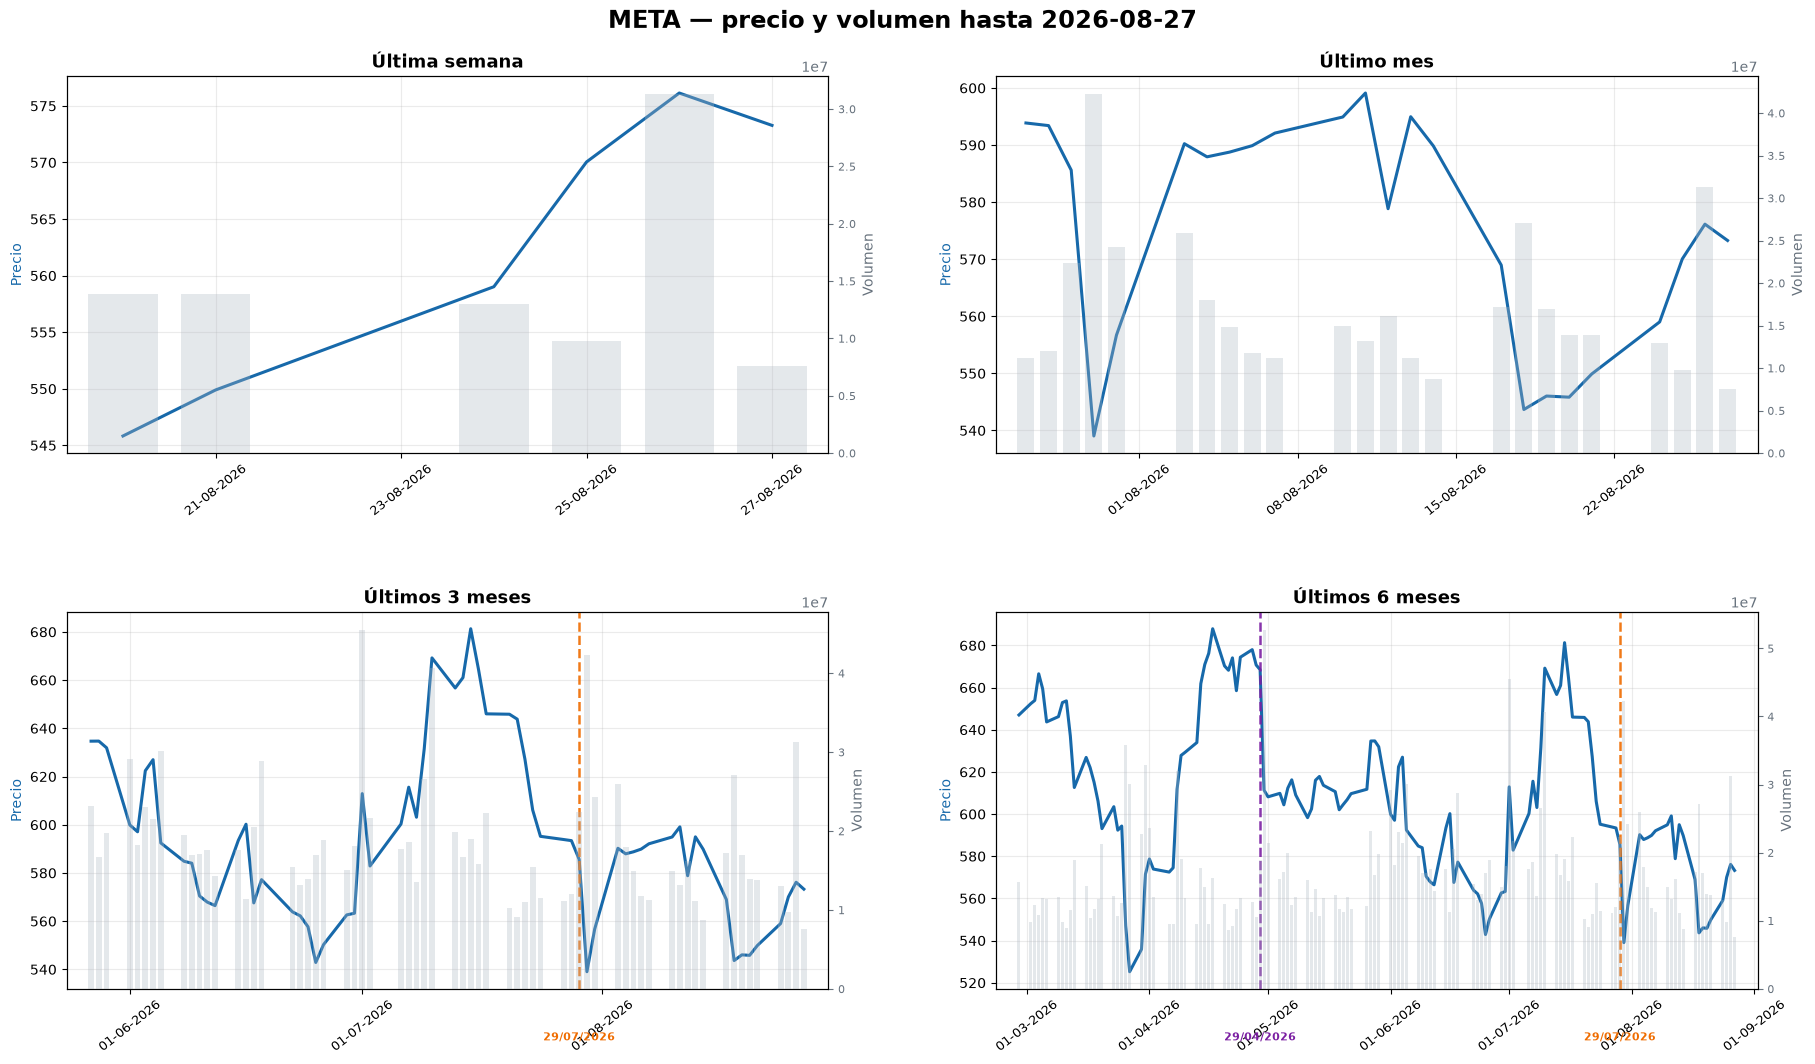

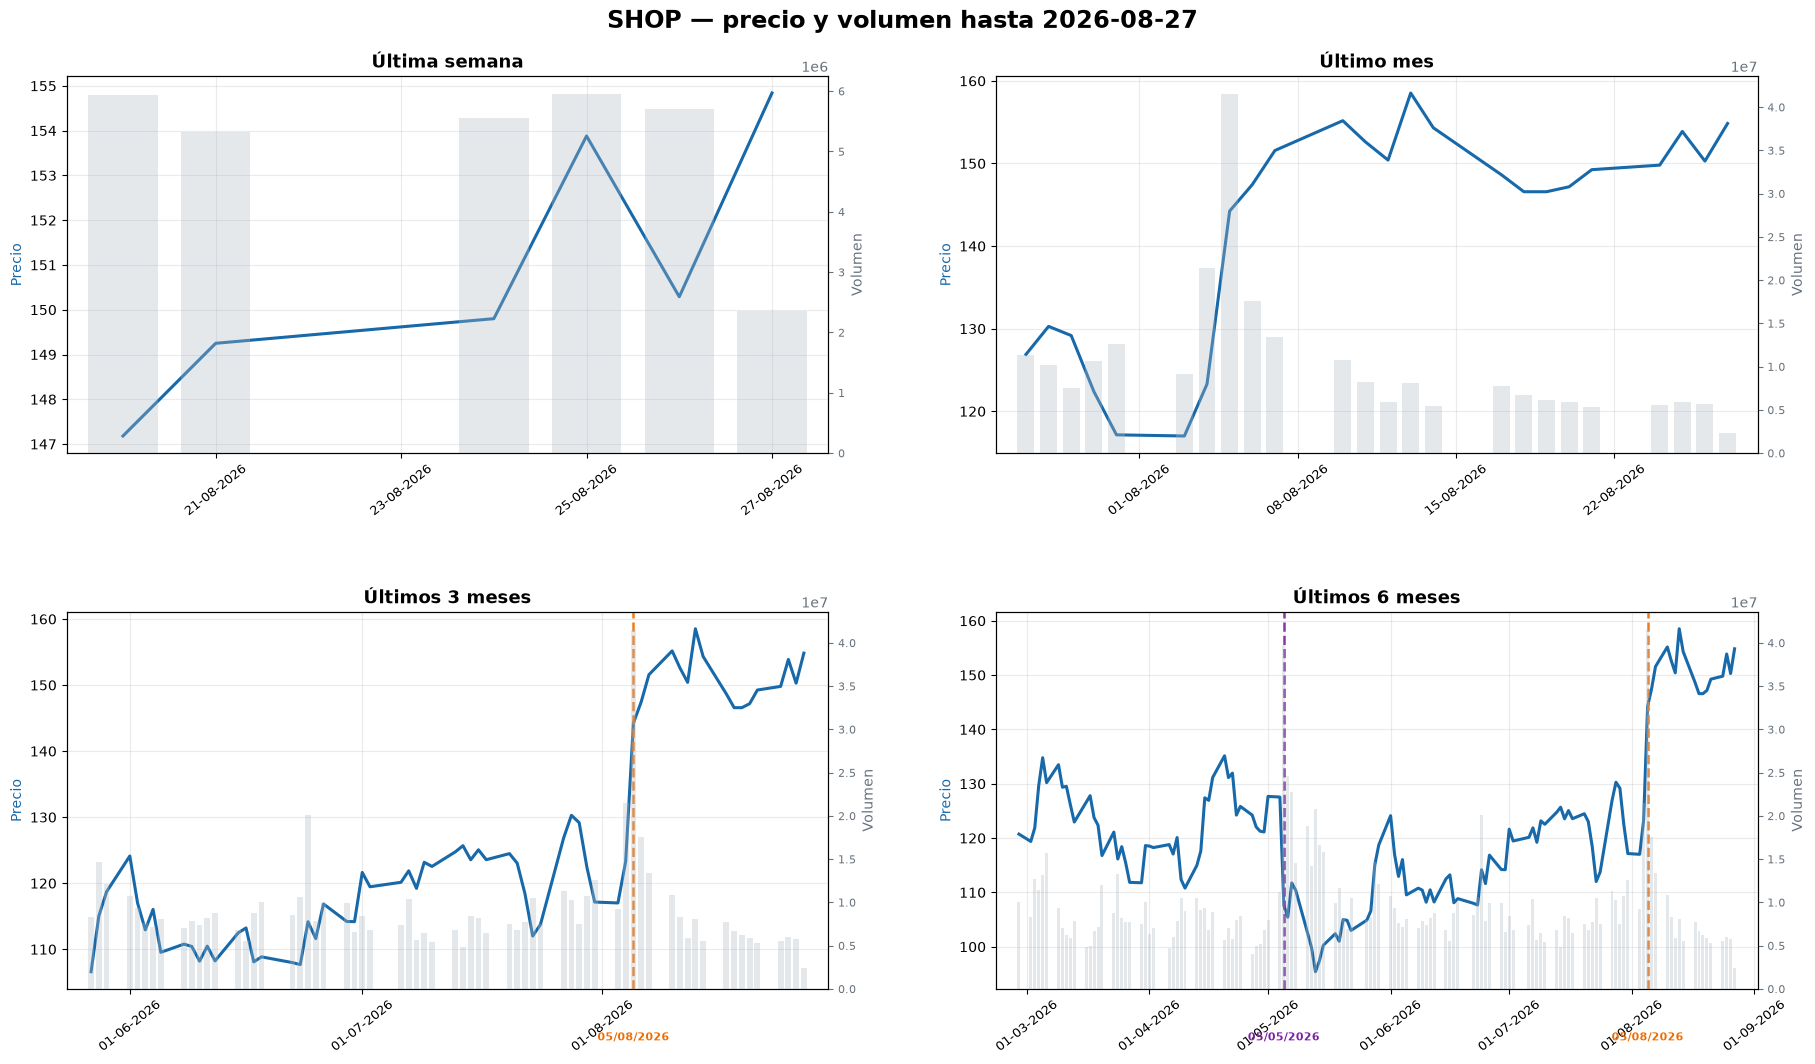

Resumen preparado para correo en: C:\Users\carlos.jimenez\Scripts_Bolsa_GitHub\salida_operativa


In [18]:
# ===================== GRÁFICOS Y PANEL OPERATIVO V2.4 =====================
def dibujar_periodo(ax_precio, d, inicio, titulo, fechas_resultados=None):
    tramo = d.loc[d.index >= inicio]
    ax_volumen = ax_precio.twinx()
    ax_volumen.bar(
        tramo.index, tramo['Volume'], color='#aeb8c2', alpha=.32,
        width=.75, label='Volumen', zorder=1
    )
    ax_precio.plot(
        tramo.index, tramo['Close'], color='#1769aa', lw=2.2,
        label='Precio de cierre', zorder=3
    )
    colores_resultados = ['#ef6c00', '#7b1fa2']
    for indice, fecha_resultado in enumerate(fechas_resultados or []):
        marca = pd.Timestamp(fecha_resultado)
        if marca < tramo.index.min() or marca > tramo.index.max():
            continue
        color = colores_resultados[indice % len(colores_resultados)]
        ax_precio.axvline(marca, color=color, lw=1.8, ls='--', alpha=.9, zorder=4)
        ax_precio.annotate(
            marca.strftime('%d/%m/%Y'), xy=(marca, 0), xycoords=('data', 'axes fraction'),
            xytext=(0, -31), textcoords='offset points', ha='center', va='top',
            fontsize=8, fontweight='bold', color=color, annotation_clip=False
        )
    ax_precio.set_title(titulo, fontsize=13, fontweight='bold')
    ax_precio.set_ylabel('Precio', color='#1769aa')
    ax_volumen.set_ylabel('Volumen', color='#66717c')
    ax_volumen.tick_params(axis='y', labelsize=8, colors='#66717c')
    ax_volumen.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax_precio.grid(alpha=.25)
    ax_precio.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=7))
    ax_precio.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
    ax_precio.tick_params(axis='x', rotation=38, labelsize=9)
    ax_precio.margins(x=.03)


def construir_alerta_resultados(ticker, fecha_referencia):
    """Construye el aviso usando la fecha analizada, no la hora de ejecución."""
    datos = DATOS_ALERTA_RESULTADOS.get(ticker, {})
    referencia = pd.Timestamp(fecha_referencia).date()
    publicadas = sorted(
        (pd.Timestamp(f).date() for f in datos.get("publicadas", []) if f),
        reverse=True,
    )
    ultima = publicadas[0] if publicadas else None
    proxima = pd.Timestamp(datos["proxima"]).date() if datos.get("proxima") else None

    dias_desde_ultima = (referencia - ultima).days if ultima else None
    # Durante los seis días posteriores prima la advertencia de cuarentena.
    if dias_desde_ultima is not None and 0 <= dias_desde_ultima <= 6:
        distancia = dias_desde_ultima
        mensaje = "Se produjeron HOY" if distancia == 0 else (
            f"Se produjeron hace {distancia} día" + ("" if distancia == 1 else "s")
        )
    elif proxima is not None:
        dias_hasta = (proxima - referencia).days
        if dias_hasta >= 0:
            distancia = dias_hasta
            mensaje = "Se producen HOY" if distancia == 0 else (
                f"Dentro de {distancia} día" + ("" if distancia == 1 else "s")
            )
        else:
            distancia = abs(dias_hasta)
            mensaje = f"Se produjeron hace {distancia} días"
    elif ultima is not None:
        distancia = abs(dias_desde_ultima)
        mensaje = f"Se produjeron hace {distancia} días"
    else:
        return {"mensaje": "Sin alertas de resultados", "color": "#5f6368"}

    if distancia <= 3:
        color = "#c62828"
    elif distancia in (5, 6):
        color = "#1565c0"
    else:
        color = "#5f6368"
    return {"mensaje": mensaje, "color": color}


def tarjeta(ticker, estado, fecha, cierre):
    accion = estado['accion']
    alerta_resultados = construir_alerta_resultados(ticker, fecha)
    if accion.startswith('ENTRAR'):
        fondo, borde = '#d9f7df', '#16823b'
    elif accion.startswith('SALIR') or accion.startswith('REVISAR STOP'):
        fondo, borde = '#ffe1df', '#c62828'
    elif accion.startswith('MANTENER'):
        fondo, borde = '#dcecff', '#2463a7'
    else:
        fondo, borde = '#eeeeee', '#666666'
    stop = '—' if estado['stop'] is None else f"{estado['stop']:,.2f}"
    return f"""
    <div style='background:{fondo};border-left:8px solid {borde};padding:14px 18px;
                margin:10px 0 28px 0;border-radius:7px;font-family:Arial'>
      <div style='font-size:21px'><b>{ticker}: {accion}</b></div>
      <div style='font-size:14px;font-weight:700;color:{alerta_resultados["color"]};
                  margin:4px 0 8px 0'>
        Alerta resultados: {alerta_resultados["mensaje"]}.
      </div>
      <div><b>Momento:</b> {estado['momento']} &nbsp;|&nbsp;
           <b>Sistema:</b> {estado['sistema']} &nbsp;|&nbsp;
           <b>Stop:</b> {stop}</div>
      <div><b>Cierre analizado:</b> {fecha:%Y-%m-%d} a {cierre:,.2f}</div>
      <div><b>Motivo:</b> {estado['motivo']}</div>
      <div style='font-size:12px;color:#555'>{estado['nota_stop']}</div>
    </div>"""


carpeta_salida = Path('salida_operativa')
carpeta_salida.mkdir(exist_ok=True)
tarjetas_html = []

print(f'PANEL OPERATIVO V2.4 — {MODO_OPERATIVO} — cierre {ultima_fecha_comun.date()}')
for ticker in tickers:
    d = datos[ticker]
    fin = d.index[-1]
    fechas_resultados = FECHAS_RESULTADOS_GRAFICOS.get(ticker, [])
    fig, axes = plt.subplots(2, 2, figsize=(19, 11))
    axes = axes.ravel()
    dibujar_periodo(axes[0], d, fin - pd.Timedelta(days=7), 'Última semana')
    dibujar_periodo(axes[1], d, fin - relativedelta(months=1), 'Último mes')
    dibujar_periodo(
        axes[2], d, fin - relativedelta(months=3), 'Últimos 3 meses', fechas_resultados
    )
    dibujar_periodo(
        axes[3], d, fin - relativedelta(months=6), 'Últimos 6 meses', fechas_resultados
    )
    fig.suptitle(f'{ticker} — precio y volumen hasta {fin:%Y-%m-%d}', fontsize=17, fontweight='bold')
    fig.subplots_adjust(left=.06, right=.95, top=.92, bottom=.09, hspace=.42, wspace=.22)
    fig.savefig(carpeta_salida / f'{ticker}_panel.png', dpi=145, bbox_inches='tight')
    plt.show()
    html_ticker = tarjeta(ticker, estados[ticker], fin, float(d['Close'].iloc[-1]))
    tarjetas_html.append(html_ticker)
    display(HTML(html_ticker))

resumen_html = f"""<!doctype html><html><body style='font-family:Arial'>
<h2>Panel operativo V2.4 — {MODO_OPERATIVO}</h2>
<p>Cierre analizado: <b>{ultima_fecha_comun.date()}</b></p>
{''.join(tarjetas_html)}
<p style='font-size:12px;color:#666'>Las indicaciones ENTRAR/SALIR se ejecutan en la próxima apertura.
Comprueba siempre las posiciones y órdenes de protección en IBKR Paper.</p>
</body></html>"""
(carpeta_salida / 'resumen_operativo.html').write_text(resumen_html, encoding='utf-8')
print('Resumen preparado para correo en:', carpeta_salida.resolve())


## Uso diario

1. Actualiza `POSICIONES_PAPER` con lo que realmente tienes ejecutado en IBKR Paper.
2. Ejecuta todas las celdas después del cierre estadounidense.
3. Una indicación `ENTRAR` o `SALIR` se refiere a la próxima apertura.
4. Introduce en `POSICIONES_PAPER` el precio y fecha reales después de una ejecución.
5. Mantén siempre la orden de protección en IBKR; este notebook no transmite ni confirma órdenes.

La disponibilidad y el coste de préstamo de una acción en corto no están incluidos en el cálculo.
